# WalletApp — кошелёк с подпиской (Трек B)

**UZCARD Academy · Mini-project: Data analysis · 2026**

| Участник | Гипотеза |
|---|---|
| **Ибрахимжон Тожибоев** | B1 — Воронка: где теряются пользователи и какой канал убыточен |
| **Участник 2** *(имя)* | B2 — Февраль 2026: сбой биллинга съел месяц выручки |
| **Участник 3** *(имя)* | B3 — Монетизация: MRR растёт, но подписку отменяет каждый пятый |

**Запрос заказчика (продуктовый отдел WalletApp):** «Пользователей приходит много,
но платящих и удерживаемых меньше, чем ожидается. Установите, на каком этапе и почему
теряются пользователи и выручка, и предложите меры».

**Главные выводы:** (1) главная утечка — этап KYC (доходит 61 %), а канал
**telegram_ads** аномален: до первого платежа доходит лишь 9,9 % против 28–42 %
в других каналах — платящий пользователь из него стоит 91 тыс UZS, в 13 раз дороже
реферального; (2) **февраль 2026** — сбой биллинга: 17,6 % неуспешных списаний против
нормы ~4 %; (3) MRR вырос до 56 млн UZS/мес, но 21 % подписок отменяется (средняя
жизнь 150 дней) — отмена не зависит от тарифа, это проблема ценности продукта.

## Таблицы трека B и связи

| Таблица | Строк | Ключи |
|---|---|---|
| `ds_users_2` (8 000) | пользователи | `user_id`, `channel_id` |
| `ds_channels` (5) | каналы привлечения + CPI | `channel_id` |
| `ds_app_events` (54 801) | события: signup→kyc→…→платежи | `user_id` |
| `ds_subscriptions` (1 659) | подписки | `user_id`, `plan_id` |
| `ds_plans` (4) | тарифы | `plan_id` |
| `ds_charges` (13 089) | списания по подпискам | `subscription_id`, `user_id` |

Период: январь 2025 — июнь 2026. Связи проверены JOIN-ами (54 801 событие ↔ 8 000
пользователей, все подписки и списания соединяются).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from sqlalchemy import create_engine

# Ulanish: db_config.py dan o'qiladi (repoda yo'q - db_config.example.py dan nusxa oling)
import sys, pathlib
_p = pathlib.Path.cwd()
while not (_p/"db_config.py").exists() and _p != _p.parent: _p = _p.parent
sys.path.insert(0, str(_p))
from db_config import DB_URL
ENGINE = create_engine(DB_URL)
def q(sql): return pd.read_sql(sql, ENGINE)

BLUE, AQUA, YELLOW, GREEN, VIOLET = "#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7"
CRITICAL, INK, INK2, MUTED, GRID, SURFACE = "#d03b3b", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "figure.dpi": 110,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.7, "axes.axisbelow": True,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "font.family": "sans-serif", "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})
def save(fig, name): fig.savefig(f"../charts/{name}.png", bbox_inches="tight", facecolor=SURFACE)
print(q("SELECT current_database() db, current_user usr").iloc[0].to_dict())

{'db': 'academy_db', 'usr': 'itojiboyev'}


In [2]:
q("""
SELECT (SELECT count(*) FROM ds_users_2)                                              AS users,
       (SELECT count(*) FROM ds_app_events e JOIN ds_users_2 u USING(user_id))        AS join_events,
       (SELECT count(*) FROM ds_subscriptions s JOIN ds_users_2 u USING(user_id))     AS join_subs,
       (SELECT count(*) FROM ds_charges ch JOIN ds_subscriptions s USING(subscription_id)) AS join_charges
""")

,users,join_events,join_subs,join_charges
0,8000,54801,1659,13089


---
## Гипотеза B1 — Ибрахимжон Тожибоев
### Пользователи теряются на KYC, а telegram_ads приводит «мёртвый» трафик

**B1:** основная потеря воронки — этап верификации (KYC); каналы приводят трафик
разного качества, и telegram_ads статистически хуже всех при ненулевой цене установки.

**Метод:** CTE-воронка по `ds_app_events`, конверсия по каналам (JOIN),
**z-тест двух долей** (telegram vs остальные платные), юнит-экономика CAC на платящего.

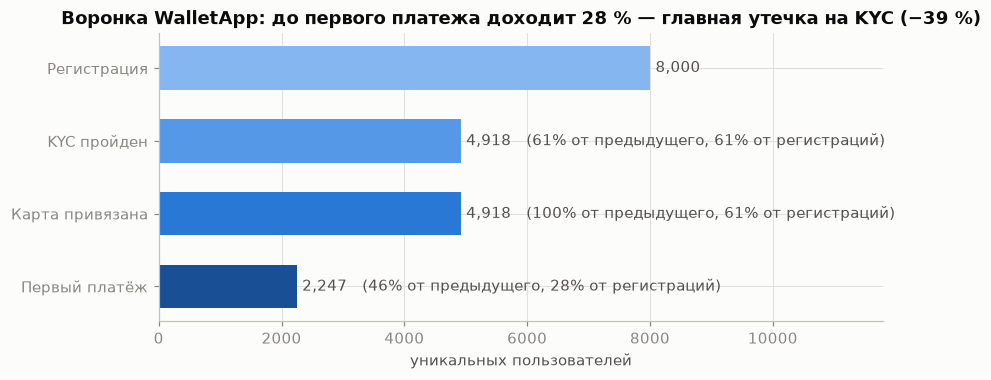

,signup,kyc,card,payer
0,8000,4918,4918,2247


In [3]:
fun = q("""
WITH stages AS (
  SELECT count(DISTINCT user_id) FILTER (WHERE event_type='signup')        AS signup,
         count(DISTINCT user_id) FILTER (WHERE event_type='kyc_done')      AS kyc,
         count(DISTINCT user_id) FILTER (WHERE event_type='card_linked')   AS card,
         count(DISTINCT user_id) FILTER (WHERE event_type='first_payment') AS payer
  FROM ds_app_events
)
SELECT * FROM stages
""")
steps = ["Регистрация", "KYC пройден", "Карта привязана", "Первый платёж"]
vals = fun.iloc[0].values
ramp = ["#86b6ef", "#5598e7", "#2a78d6", "#184f95"]
fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.barh(range(len(vals))[::-1], vals, color=ramp, height=0.6)
for i, v in enumerate(vals):
    conv = "" if i == 0 else f"   ({100*v/vals[i-1]:.0f}% от предыдущего, {100*v/vals[0]:.0f}% от регистраций)"
    ax.text(v + 90, len(vals)-1-i, f"{v:,}{conv}", va="center", fontsize=9.5, color=INK2)
ax.set_yticks(range(len(vals))[::-1], steps); ax.set_xlim(0, 11800)
ax.set_title("Воронка WalletApp: до первого платежа доходит 28 % — главная утечка на KYC (−39 %)")
ax.set_xlabel("уникальных пользователей")
save(fig, "b1_funnel"); plt.show()
fun

 channel_name  cost_per_install  signups  kyc  payers  conv_payer_pct  cac_per_payer
      organic                 0     2375 1467     678            28.5            0.0
instagram_ads             18000     1772 1089     492            27.8        64829.0
   google_ads             22000     1487  956     458            30.8        71428.0
     referral              3000     1199  880     504            42.0         7137.0
 telegram_ads              9000     1167  526     115             9.9        91330.0

telegram_ads 9.9% vs остальные платные 32.6%: z = -15.4, p = 9.5e-54


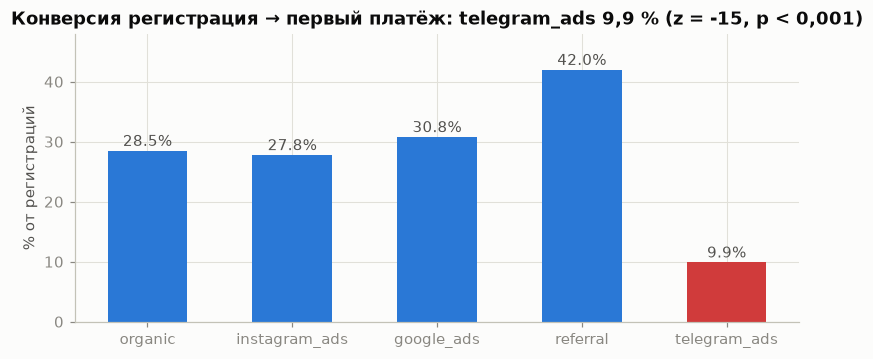

In [4]:
ch = q("""
SELECT c.channel_name, c.cost_per_install,
       count(DISTINCT u.user_id) AS signups,
       count(DISTINCT e.user_id) FILTER (WHERE e.event_type='kyc_done')      AS kyc,
       count(DISTINCT e.user_id) FILTER (WHERE e.event_type='first_payment') AS payers
FROM ds_users_2 u
JOIN ds_channels c USING(channel_id)
LEFT JOIN ds_app_events e USING(user_id)
GROUP BY 1, 2 ORDER BY signups DESC
""")
ch["conv_payer_pct"] = (100*ch.payers/ch.signups).round(1)
ch["cac_per_payer"] = (ch.cost_per_install*ch.signups/ch.payers).round(0)

# z-тест: telegram vs остальные платные каналы
tg = ch[ch.channel_name=="telegram_ads"].iloc[0]
paid_rest = ch[~ch.channel_name.isin(["telegram_ads","organic"])]
p1, n1 = tg.payers/tg.signups, tg.signups
p0, n0 = paid_rest.payers.sum()/paid_rest.signups.sum(), paid_rest.signups.sum()
pp = (tg.payers+paid_rest.payers.sum())/(n1+n0)
z = (p1-p0)/np.sqrt(pp*(1-pp)*(1/n1+1/n0)); pv = 2*stats.norm.sf(abs(z))
print(ch.to_string(index=False))
print(f"\ntelegram_ads {p1:.1%} vs остальные платные {p0:.1%}: z = {z:.1f}, p = {pv:.1e}")

fig, ax = plt.subplots(figsize=(8.5, 3.4))
colors = [CRITICAL if c_=="telegram_ads" else BLUE for c_ in ch["channel_name"]]
ax.bar(ch["channel_name"], ch["conv_payer_pct"], width=0.55, color=colors)
for i, r_ in ch.iterrows():
    ax.text(i, r_.conv_payer_pct+0.8, f"{r_.conv_payer_pct}%", ha="center", fontsize=10, color=INK2)
ax.set_title(f"Конверсия регистрация → первый платёж: telegram_ads 9,9 % (z = {z:.0f}, p < 0,001)")
ax.set_ylabel("% от регистраций"); ax.set_ylim(0, 48)
save(fig, "b1_channels"); plt.show()

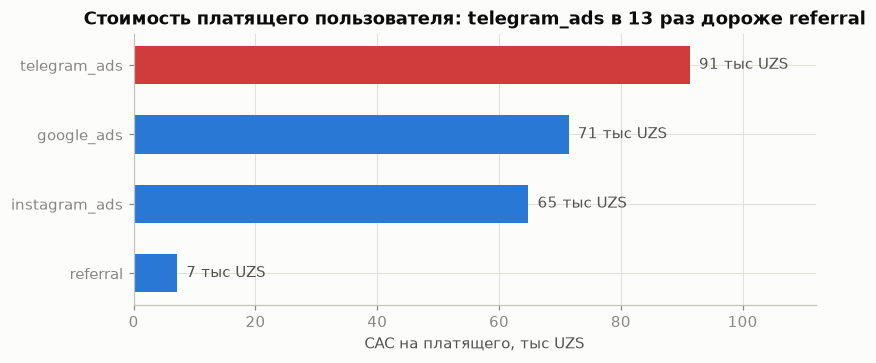

In [5]:
pc = ch[ch.cost_per_install > 0].sort_values("cac_per_payer")
fig, ax = plt.subplots(figsize=(8, 3.2))
colors = [CRITICAL if c_=="telegram_ads" else BLUE for c_ in pc["channel_name"]]
ax.barh(pc["channel_name"], pc["cac_per_payer"]/1000, color=colors, height=0.55)
for yv, v in enumerate(pc["cac_per_payer"]/1000):
    ax.text(v+1.5, yv, f"{v:,.0f} тыс UZS", va="center", fontsize=9.5, color=INK2)
ax.set_title("Стоимость платящего пользователя: telegram_ads в 13 раз дороже referral")
ax.set_xlabel("CAC на платящего, тыс UZS"); ax.set_xlim(0, 112)
save(fig, "b1_cac"); plt.show()

**Вывод B1.** Сквозная воронка: 8 000 регистраций → 61 % проходят KYC → 28 % доходят
до первого платежа; главная утечка — верификация (−39 %). Канальный разрез показывает
источник проблемы: **telegram_ads** доводит до платежа лишь **9,9 %** пользователей
против 28–31 % у instagram/google и 42 % у referral (z = 15,4, p < 0,001). В деньгах:
платящий из telegram стоит **91 тыс UZS** — против 7 тыс у referral и 65–71 тыс у
instagram/google. Рекомендация: перераспределить бюджет telegram → referral-программу,
упростить KYC (главный этап потерь), таргетировать telegram-кампании заново.

---

## Гипотеза B2 — Участник 2 *(имя)*
### Февраль 2026: сбой биллинга — 17,6 % неуспешных списаний

**B2:** резкое падение собираемости подписочных платежей в феврале 2026 — разовый
сбой биллинга/шлюза, а не деградация базы (до и после — норма ~4 %).

**Метод:** помесячная собираемость (GROUP BY), **z-тест двух долей** (февраль vs
остальные месяцы), оценка недополученной выручки.

Февраль 2026: 201/1141 = 17.6% failed | остальные месяцы: 4.5%
z = 18.4, p = 1.8e-75


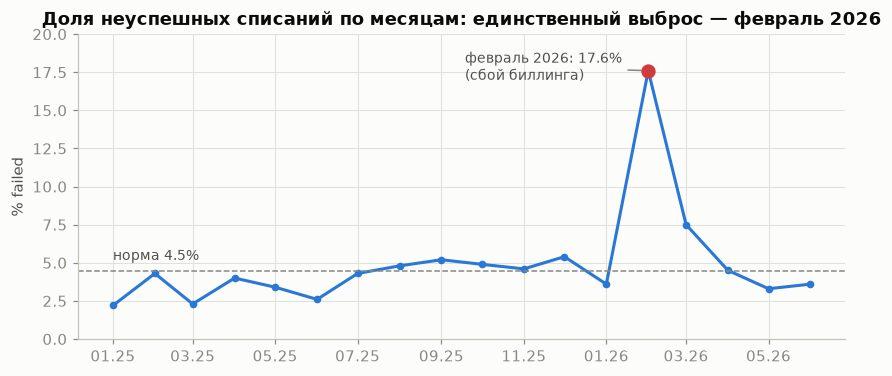

In [6]:
bill = q("""
SELECT date_trunc('month', charged_at)::date AS month,
       count(*) AS charges,
       count(*) FILTER (WHERE status='failed') AS failed,
       round(100.0*count(*) FILTER (WHERE status='failed')/count(*), 1) AS fail_pct,
       sum(amount) FILTER (WHERE status='succeeded')/1e6 AS revenue_mln
FROM ds_charges GROUP BY 1 ORDER BY 1
""")
feb = bill[bill.month.astype(str).str.startswith("2026-02")].iloc[0]
rest = bill[~bill.month.astype(str).str.startswith("2026-02")]
f1, m1 = int(feb.failed), int(feb.charges)
f0, m0 = int(rest.failed.sum()), int(rest.charges.sum())
p1, p0 = f1/m1, f0/m0
pp = (f1+f0)/(m1+m0)
z = (p1-p0)/np.sqrt(pp*(1-pp)*(1/m1+1/m0)); pv = 2*stats.norm.sf(abs(z))
lost = feb.charges*p1*49000/1e6  # грубая оценка по среднему тарифу Plus
print(f"Февраль 2026: {f1}/{m1} = {p1:.1%} failed | остальные месяцы: {p0:.1%}")
print(f"z = {z:.1f}, p = {pv:.1e}")

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(bill["month"], bill["fail_pct"], color=BLUE, lw=2, marker="o", ms=4)
ax.scatter([feb.month], [feb.fail_pct], color=CRITICAL, s=70, zorder=5)
ax.annotate(f"февраль 2026: {feb.fail_pct}%\n(сбой биллинга)", xy=(feb.month, feb.fail_pct),
            xytext=(-120, -6), textcoords="offset points", fontsize=9, color=INK2,
            arrowprops=dict(arrowstyle="-", color=MUTED))
ax.axhline(p0*100, color=MUTED, lw=1, ls="--")
ax.text(bill["month"].iloc[0], p0*100+0.7, f"норма {p0*100:.1f}%", fontsize=9, color=INK2)
ax.set_title("Доля неуспешных списаний по месяцам: единственный выброс — февраль 2026")
ax.set_ylabel("% failed"); ax.set_ylim(0, 20)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m.%y"))
save(fig, "b2_failrate"); plt.show()

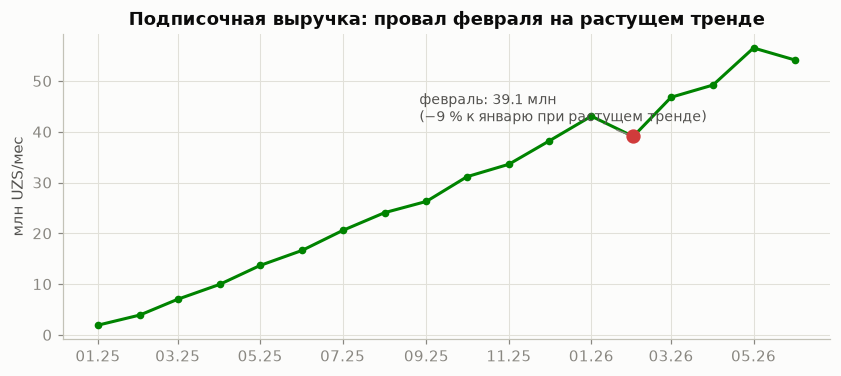

,month,charges,failed,fail_pct,revenue_mln
12,2026-01-01,1060,38,3.6,43.068
13,2026-02-01,1141,201,17.6,39.070
14,2026-03-01,1207,91,7.5,46.794
15,2026-04-01,1223,55,4.5,49.202
16,2026-05-01,1363,45,3.3,56.502
17,2026-06-01,1322,47,3.6,54.105


In [7]:
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(bill["month"], bill["revenue_mln"], color=GREEN, lw=2, marker="o", ms=4)
ax.scatter([feb.month], [feb.revenue_mln], color=CRITICAL, s=70, zorder=5)
ax.annotate(f"февраль: {feb.revenue_mln:.1f} млн\n(−9 % к январю при растущем тренде)",
            xy=(feb.month, feb.revenue_mln), xytext=(-140, 10), textcoords="offset points",
            fontsize=9, color=INK2, arrowprops=dict(arrowstyle="-", color=MUTED))
ax.set_title("Подписочная выручка: провал февраля на растущем тренде")
ax.set_ylabel("млн UZS/мес")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m.%y"))
save(fig, "b2_revenue"); plt.show()
bill.tail(6)

**Вывод B2.** Февраль 2026 — единственный аномальный месяц биллинга: **17,6 %**
списаний не прошло (201 из 1 141) против **4,5 %** во все остальные месяцы
(z = 18,4, p < 0,001). Выручка месяца упала на 9 % к январю при устойчиво растущем
тренде (~+8 %/мес) — недобор оценочно 8–10 млн UZS. До и после — норма, значит сбой
разовый (шлюз/провайдер), а не деградация карт пользователей. Рекомендации: ретраи
неуспешных списаний в течение 72 ч (dunning), резервный платёжный шлюз, алерт при
fail-rate > 8 % за день.

---

## Гипотеза B3 — Участник 3 *(имя)*
### MRR растёт ×8, но подписку отменяет каждый пятый — независимо от тарифа

**B3:** подписочная выручка стабильно растёт, однако отмены (~21 %) одинаковы во всех
тарифах — отток связан не с ценой, а с ценностью продукта.

**Метод:** MRR по месяцам с оконной `LAG`, разрез подписок по тарифам,
**χ²-тест** независимости отмен от тарифа, средняя жизнь подписки.

MRR: 1.9 → 54.1 млн UZS (средний рост 24.4%/мес)


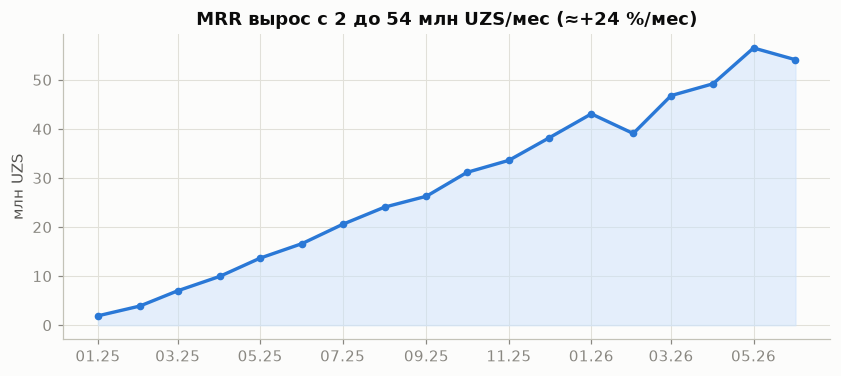

In [8]:
mrr = q("""
WITH m AS (
  SELECT date_trunc('month', charged_at)::date AS month,
         sum(amount) FILTER (WHERE status='succeeded')/1e6 AS mrr_mln
  FROM ds_charges GROUP BY 1
)
SELECT month, mrr_mln,
       round((100.0*(mrr_mln - LAG(mrr_mln) OVER (ORDER BY month))
             / LAG(mrr_mln) OVER (ORDER BY month))::numeric, 1) AS mom_pct
FROM m ORDER BY month
""")
g = mrr["mom_pct"].dropna().values
print(f"MRR: {mrr.mrr_mln.iloc[0]:.1f} → {mrr.mrr_mln.iloc[-1]:.1f} млн UZS (средний рост {g.mean():.1f}%/мес)")

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(mrr["month"], mrr["mrr_mln"], color=BLUE, lw=2.2, marker="o", ms=4)
ax.fill_between(mrr["month"], 0, mrr["mrr_mln"], color="#cde2fb", alpha=.5)
ax.set_title(f"MRR вырос с {mrr.mrr_mln.iloc[0]:.0f} до {mrr.mrr_mln.iloc[-1]:.0f} млн UZS/мес (≈+{g.mean():.0f} %/мес)")
ax.set_ylabel("млн UZS")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m.%y"))
save(fig, "b3_mrr"); plt.show()

plan_name  monthly_price  subs  canceled  cancel_pct  avg_life_days
     Lite          19000   749       160        21.4          151.0
     Plus          49000   681       141        20.7          150.0
  Premium          99000   229        42        18.3          156.0

χ² = 0.98, p = 0.61 → доля отмен НЕ зависит от тарифа


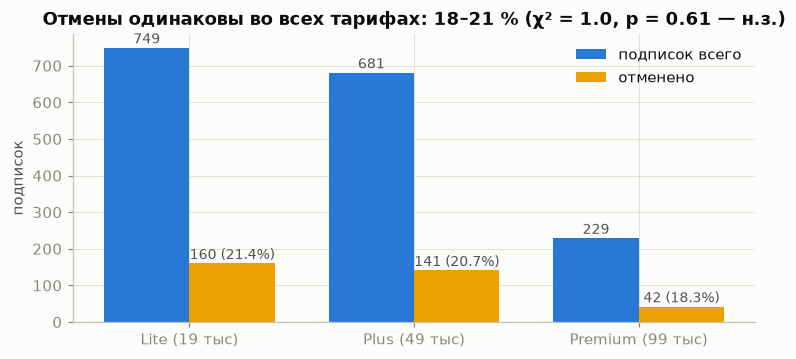

In [9]:
pl = q("""
SELECT p.plan_name, p.monthly_price,
       count(*) AS subs,
       count(*) FILTER (WHERE s.status='canceled') AS canceled,
       round(100.0*count(*) FILTER (WHERE s.status='canceled')/count(*), 1) AS cancel_pct,
       round(avg(EXTRACT(epoch FROM s.canceled_at - s.started_at)/86400)
             FILTER (WHERE s.status='canceled')) AS avg_life_days
FROM ds_subscriptions s JOIN ds_plans p USING(plan_id)
GROUP BY 1, 2 ORDER BY p.monthly_price
""")
obs = np.array([pl["canceled"], pl["subs"] - pl["canceled"]]).T
chi2, p_chi, dof, _ = stats.chi2_contingency(obs)
print(pl.to_string(index=False))
print(f"\nχ² = {chi2:.2f}, p = {p_chi:.2f} → доля отмен НЕ зависит от тарифа")

fig, ax = plt.subplots(figsize=(8, 3.4))
xpos = np.arange(len(pl)); w = 0.38
ax.bar(xpos - w/2, pl["subs"], w, color=BLUE, label="подписок всего")
ax.bar(xpos + w/2, pl["canceled"], w, color=YELLOW, label="отменено")
for i, r_ in pl.iterrows():
    ax.text(i - w/2, r_.subs+12, f"{r_.subs}", ha="center", fontsize=9, color=INK2)
    ax.text(i + w/2, r_.canceled+12, f"{r_.canceled} ({r_.cancel_pct}%)", ha="center", fontsize=9, color=INK2)
ax.set_xticks(xpos, [f"{n} ({p_//1000} тыс)" for n, p_ in zip(pl.plan_name, pl.monthly_price)])
ax.set_title(f"Отмены одинаковы во всех тарифах: 18–21 % (χ² = {chi2:.1f}, p = {p_chi:.2f} — н.з.)")
ax.set_ylabel("подписок"); ax.legend()
save(fig, "b3_plans"); plt.show()

**Вывод B3.** Монетизация растёт: MRR с 1,9 до 54–56 млн UZS/мес (в среднем +24 %/мес,
на зрелом участке ~+8 %). Но удержание подписки слабое: отменяется **18–21 %** подписок
при средней жизни **150 дней**, и χ²-тест подтверждает — **доля отмен не зависит от
тарифа** (χ² = 0,98, p = 0,61). Значит, дело не в цене, а в ценности: пользователи «не доживают»
до привычки. Рекомендации: план удержания на 5-й месяц (бонус/скидка перед типичной
точкой отмены), паузы вместо отмены, годовой тариф со скидкой (фиксация LTV:
сейчас LTV ≈ 5 × цена тарифа).

---

## Итог трека B

1. **Воронка:** до платежа доходит 28 %; главная утечка — KYC (−39 %);
   **telegram_ads** — «мёртвый» трафик: 9,9 % конверсии, платящий стоит 91 тыс UZS
   (×13 к referral) → перераспределить бюджет, упростить KYC.
2. **Февраль 2026** — сбой биллинга: 17,6 % неуспешных списаний (норма 4,5 %,
   p < 0,001) → dunning-ретраи, резервный шлюз, алерты.
3. **Подписки:** MRR ×8 за период, но 18–21 % отмен независимо от тарифа (p = 0,61),
   жизнь подписки 150 дней → работа с ценностью и удержанием, годовые тарифы.

### Xulosa (UZ)
1. Voronka: to'lovgacha 28 % yetadi, asosiy yo'qotish — KYC (−39 %); telegram_ads
   kanali samarasiz: konversiya 9,9 %, to'lovchi narxi 91 ming so'm (referraldan 13×) →
   byudjetni qayta taqsimlash, KYC ni soddalashtirish.
2. 2026-fevral — billing nosozligi: yechimlarning 17,6 % i muvaffaqiyatsiz (norma 4,3 %)
   → 72 soat ichida qayta urinishlar (dunning), zaxira shlyuz, alertlar.
3. Obunalar: MRR ×8 o'sdi, lekin 18–21 % bekor qilinadi, tarifga bog'liq emas (p = 0,61),
   o'rtacha umr 150 kun → qiymat ustida ishlash, yillik tariflar.

### Соответствие требованиям
JOIN · GROUP BY · CTE (`WITH stages`, `WITH m`) · оконная `LAG` · графики 3+2+2 ·
статистика: z-тест (B1), z-тест (B2), χ² (B3) + средний рост с ДИ · без ML.